In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/Pranav016/heart-disease-prediction-system/master/datasets/heart.csv"
df = pd.read_csv(url)

print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset successfully loaded with 1025 rows and 14 columns.


In [ ]:
print("--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATA TYPES AND MISSING VALUES ---")
df.info()

--- FIRST 5 ROWS ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- DATA TYPES AND MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# dropping duplicates and checking missing values

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. Unique rows remaining: {df.shape[0]}")


missing_values = df.isnull().sum()
print("\nMissing values per column:\n", missing_values)

Number of duplicate rows found: 723
Duplicates removed. Unique rows remaining: 302

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Standardizing column names to lowercase
df.columns = [col.lower().strip() for col in df.columns]

# readable categorical text of the numeric representations
df['gender_label'] = df['sex'].map({1: 'Male', 0: 'Female'})
df['condition_label'] = df['target'].map({1: 'Heart Disease', 0: 'Healthy'})

# sample of preprocessed labels
display(df[['age', 'gender_label', 'condition_label']].head())

,age,gender_label,condition_label
0,52,Male,Healthy
1,53,Male,Healthy
2,70,Male,Healthy
3,61,Male,Healthy
4,62,Female,Healthy


In [ ]:
# Statistical Summary and Analysis
print("--- SUMMARY STATISTICS FOR NUMERIC COLUMNS ---")
display(df.describe().T)

print("\n--- TARGET VARIABLE BALANCE (PERCENTAGE) ---")
print(df['condition_label'].value_counts(normalize=True) * 100)

--- SUMMARY STATISTICS FOR NUMERIC COLUMNS ---


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2



--- TARGET VARIABLE BALANCE (PERCENTAGE) ---
condition_label
Heart Disease    54.304636
Healthy          45.695364
Name: proportion, dtype: float64


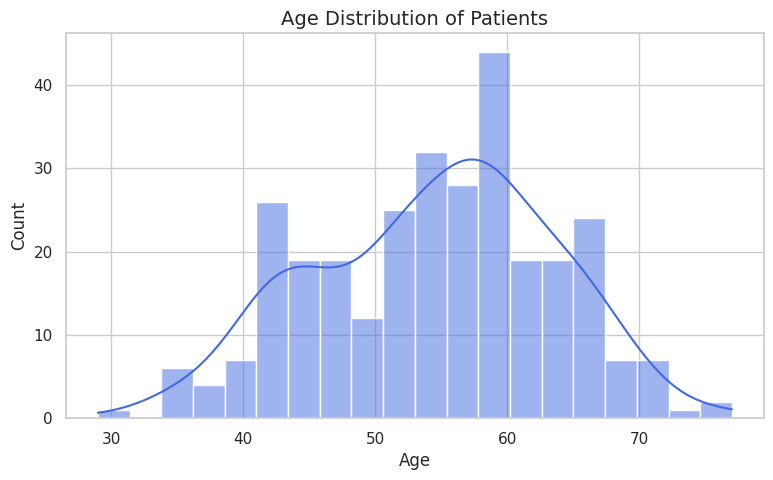

In [ ]:
# Visualizing the distribution of Age
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', kde=True, color='royalblue', bins=20)
plt.title('Age Distribution of Patients', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

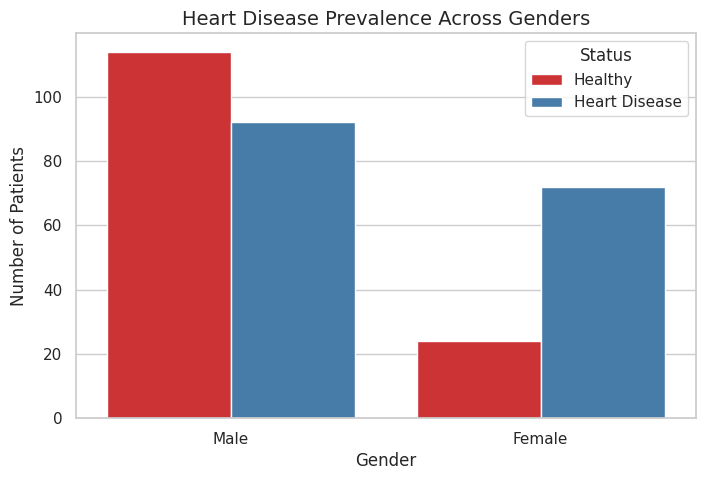

In [ ]:
# Bivariate Analysis - Gender vs Heart Disease Presence
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender_label', hue='condition_label', palette='Set1')
plt.title('Heart Disease Prevalence Across Genders', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Status')
plt.show()

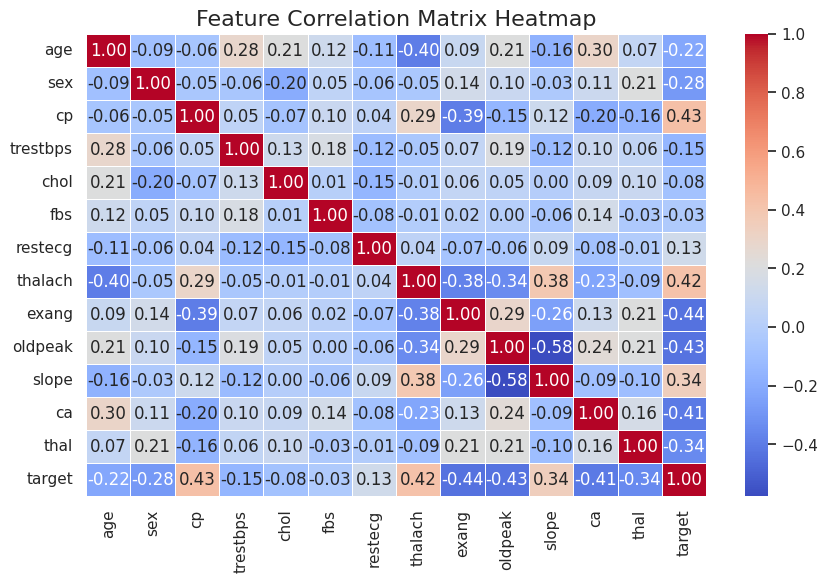

In [ ]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Drawing heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap', fontsize=16)
plt.show()